In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [2]:
"""
NOTEBOOK FIXED - Danh sách các fix so với bản gốc:

FIX 1 (Step 1+2): ViCTSD binarize Toxicity >= 2 thay vì >= 1
FIX 2 (Step 4+5): TARGET_CLEAN_SIZE tăng lên 100k (trước là 80k) để cân bằng
                  hơn với toxic/spam sau augment
FIX 3 (Step 6b):  - Loại bỏ exact duplicate trong SyntheticSpam/SyntheticHam
                    trước khi upsample (drop_duplicates trên text)
                  - Upsample ViSpamReviews riêng lên TARGET_VISPAM=30000
                    thay vì gộp chung vào spam_upsampled
                  - Giữ nguyên SyntheticToxicSpam nhưng tăng diversity template
FIX 4 (Step 8):   Thêm warmup_ratio=0.06, tăng num_train_epochs=4,
                  thêm per-task pos_weight vào custom loss
FIX 5 (Step 9):   Tối ưu threshold riêng cho từng task trên valid set
                  thay vì dùng 0.5 cố định
"""

'\nNOTEBOOK FIXED - Danh sách các fix so với bản gốc:\n\nFIX 1 (Step 1+2): ViCTSD binarize Toxicity >= 2 thay vì >= 1\nFIX 2 (Step 4+5): TARGET_CLEAN_SIZE tăng lên 100k (trước là 80k) để cân bằng\n                  hơn với toxic/spam sau augment\nFIX 3 (Step 6b):  - Loại bỏ exact duplicate trong SyntheticSpam/SyntheticHam\n                    trước khi upsample (drop_duplicates trên text)\n                  - Upsample ViSpamReviews riêng lên TARGET_VISPAM=30000\n                    thay vì gộp chung vào spam_upsampled\n                  - Giữ nguyên SyntheticToxicSpam nhưng tăng diversity template\nFIX 4 (Step 8):   Thêm warmup_ratio=0.06, tăng num_train_epochs=4,\n                  thêm per-task pos_weight vào custom loss\nFIX 5 (Step 9):   Tối ưu threshold riêng cho từng task trên valid set\n                  thay vì dùng 0.5 cố định\n'

In [3]:
# =========================================================
# STEP 1 + STEP 2  (LOAD + STANDARDIZE)
# =========================================================
# FIX 1: ViCTSD dùng Toxicity >= 2 thay vì >= 1
# Lý do: Toxicity=1 là "borderline", signal rất nhiễu.
#        Từ 2 trở lên mới là toxic rõ ràng.
# =========================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

victsd_splits = {
    "train": "ViCTSD_train.csv",
    "validation": "ViCTSD_valid.csv",
    "test": "ViCTSD_test.csv"
}

victsd_df = pd.concat([
    pd.read_csv(f"hf://datasets/tarudesu/ViCTSD/{file}")
    for file in victsd_splits.values()
], ignore_index=True)

print(f"ViCTSD: {victsd_df.shape}")
print("ViCTSD Toxicity distribution:")
print(victsd_df["Toxicity"].value_counts().sort_index())

vihsd_df = pd.read_csv("hf://datasets/visolex/ViHSD/ViHSD.csv")
print(f"ViHSD: {vihsd_df.shape}")

vispam_df = pd.read_csv("hf://datasets/visolex/ViSpamReviews/ViSpamReviews.csv")
print(f"ViSpamReviews: {vispam_df.shape}")

spam_splits = {
    "train": "data/train-00000-of-00001-daf190ce720b3dbb.parquet",
    "test":  "data/test-00000-of-00001-fa9b3e8ade89a333.parquet"
}
english_spam_df = pd.concat([
    pd.read_parquet("hf://datasets/Deysi/spam-detection-dataset/" + v)
    for v in spam_splits.values()
], ignore_index=True)
print(f"English Spam: {english_spam_df.shape}")

synthetic_ham_df  = pd.read_csv(
    "/kaggle/input/datasets/nguynxunphc/synthetic-vietnamese-data/vietnamese_ham_dataset.csv"
)
synthetic_spam_df = pd.read_csv(
    "/kaggle/input/datasets/nguynxunphc/synthetic-vietnamese-data/vietnamese_spam_dataset_kaggle.csv"
)
print(f"Synthetic Ham : {synthetic_ham_df.shape}")
print(f"Synthetic Spam: {synthetic_spam_df.shape}")

jigsaw_train_df = pd.read_csv(
    "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv"
)
print(f"Jigsaw: {jigsaw_train_df.shape}")

LOADING DATASETS
ViCTSD: (10000, 6)
ViCTSD Toxicity distribution:
Toxicity
0    8899
1    1101
Name: count, dtype: int64
ViHSD: (33400, 4)
ViSpamReviews: (19870, 6)
English Spam: (10900, 2)
Synthetic Ham : (10011, 7)
Synthetic Spam: (10000, 7)
Jigsaw: (159571, 8)


In [4]:
# =========================================================
# STANDARDIZE + LABEL MAPPING
# =========================================================

print("\n" + "=" * 80)
print("STANDARDIZING DATASETS")
print("=" * 80)

standardized_dfs = []

# ViCTSD — FIX 1: threshold >= 2
victsd_final = pd.DataFrame({
    "text":   victsd_df["Comment"].astype(str),
    # FIX 1: Toxicity >= 2 (bỏ borderline level 1)
    "toxic":  (victsd_df["Toxicity"].fillna(0) >= 2).astype(int),
    "spam":   0,
    "lang":   "vi",
    "source": "ViCTSD"
})
standardized_dfs.append(victsd_final)
print(f"ViCTSD done: {victsd_final.shape} | toxic rate: {victsd_final['toxic'].mean():.3f}")

# ViHSD
vihsd_final = pd.DataFrame({
    "text":   vihsd_df["free_text"].astype(str),
    "toxic":  (vihsd_df["label_id"] != 0).astype(int),
    "spam":   0,
    "lang":   "vi",
    "source": "ViHSD"
})
standardized_dfs.append(vihsd_final)
print(f"ViHSD done: {vihsd_final.shape} | toxic rate: {vihsd_final['toxic'].mean():.3f}")

# ViSpamReviews
vispam_final = pd.DataFrame({
    "text":   vispam_df["Comment"].astype(str),
    "toxic":  0,
    "spam":   (vispam_df["SpamLabel"] != 0).astype(int),
    "lang":   "vi",
    "source": "ViSpamReviews"
})
standardized_dfs.append(vispam_final)
print(f"ViSpamReviews done: {vispam_final.shape} | spam rate: {vispam_final['spam'].mean():.3f}")

# English Spam
english_spam_final = pd.DataFrame({
    "text":   english_spam_df["text"].astype(str),
    "toxic":  0,
    "spam":   (
        english_spam_df["label"]
        .map({"not_spam": 0, "spam": 1})
        .fillna(0)
        .astype(int)
    ),
    "lang":   "en",
    "source": "EnglishSpam"
})
standardized_dfs.append(english_spam_final)
print(f"EnglishSpam done: {english_spam_final.shape} | spam rate: {english_spam_final['spam'].mean():.3f}")

# Synthetic Ham
synthetic_ham_final = pd.DataFrame({
    "text":   synthetic_ham_df["text"].astype(str),
    "toxic":  0,
    "spam":   0,
    "lang":   "vi",
    "source": "SyntheticHam"
})
standardized_dfs.append(synthetic_ham_final)

# Synthetic Spam
synthetic_spam_final = pd.DataFrame({
    "text":   synthetic_spam_df["text"].astype(str),
    "toxic":  0,
    "spam":   1,
    "lang":   "vi",
    "source": "SyntheticSpam"
})
standardized_dfs.append(synthetic_spam_final)
print(f"SyntheticSpam done: {synthetic_spam_final.shape}")

# Jigsaw
toxic_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
jigsaw_final = pd.DataFrame({
    "text":   jigsaw_train_df["comment_text"].astype(str),
    "toxic":  (jigsaw_train_df[toxic_cols].sum(axis=1) > 0).astype(int),
    "spam":   0,
    "lang":   "en",
    "source": "Jigsaw"
})
standardized_dfs.append(jigsaw_final)
print(f"Jigsaw done: {jigsaw_final.shape} | toxic rate: {jigsaw_final['toxic'].mean():.3f}")

final_df = pd.concat(standardized_dfs, ignore_index=True)

# Basic cleaning
before = len(final_df)
final_df = final_df.dropna(subset=["text"])
final_df["text"] = final_df["text"].astype(str).str.strip()
final_df = final_df[final_df["text"].str.len() > 0]
final_df = final_df.drop_duplicates(subset=["text", "toxic", "spam"])
after = len(final_df)

print(f"\nBefore cleaning : {before}")
print(f"After cleaning  : {after}")
print(f"Removed         : {before - after}")
print("\nToxic Distribution:")
print(final_df["toxic"].value_counts())
print("\nSpam Distribution:")
print(final_df["spam"].value_counts())


STANDARDIZING DATASETS
ViCTSD done: (10000, 5) | toxic rate: 0.000
ViHSD done: (33400, 5) | toxic rate: 0.173
ViSpamReviews done: (19870, 5) | spam rate: 0.265
EnglishSpam done: (10900, 5) | spam rate: 0.505
SyntheticSpam done: (10000, 5)
Jigsaw done: (159571, 5) | toxic rate: 0.102

Before cleaning : 253752
After cleaning  : 250822
Removed         : 2930

Toxic Distribution:
toxic
0    229068
1     21754
Name: count, dtype: int64

Spam Distribution:
spam
0    230075
1     20747
Name: count, dtype: int64


In [5]:
# =========================================================
# STEP 3 — CLEANING + NORMALIZATION
# (giữ nguyên, không đổi)
# =========================================================

import re
import unicodedata

print("=" * 80)
print("STEP 3 - CLEANING + NORMALIZATION")
print("=" * 80)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"[\u200b\u200c\u200d\uFEFF]", "", text)
    text = text.replace("\r", "\n").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"([!?.,])\1{4,}", r"\1\1\1", text)
    text = text.strip()
    return text

before_cleaning = len(final_df)

final_df["text"] = final_df["text"].apply(clean_text)
final_df = final_df[final_df["text"].str.len() > 0]
final_df["char_len"] = final_df["text"].str.len()
final_df["word_len"] = final_df["text"].str.split().str.len()

MAX_CHAR_LEN = 3000
MAX_WORD_LEN = 500
MIN_CHAR_LEN = 2

final_df = final_df[
    (final_df["char_len"] <= MAX_CHAR_LEN) &
    (final_df["word_len"] <= MAX_WORD_LEN) &
    (final_df["char_len"] >= MIN_CHAR_LEN)
]

before_dedup = len(final_df)
final_df = final_df.drop_duplicates(subset=["text", "toxic", "spam"])
after_dedup = len(final_df)

final_df = final_df.reset_index(drop=True)

final_df["label"] = 0
final_df.loc[(final_df["toxic"] == 1) & (final_df["spam"] == 0), "label"] = 1
final_df.loc[(final_df["toxic"] == 0) & (final_df["spam"] == 1), "label"] = 2
final_df.loc[(final_df["toxic"] == 1) & (final_df["spam"] == 1), "label"] = 3

print(f"\nShape: {final_df.shape}")
print(f"Before dedup: {before_dedup} | After dedup: {after_dedup}")
print("\nLabel distribution:")
print(final_df["label"].value_counts().sort_index())
print("\nSource distribution:")
print(final_df["source"].value_counts())

print("\nSTEP 3 DONE.")

STEP 3 - CLEANING + NORMALIZATION

Shape: (248275, 8)
Before dedup: 248519 | After dedup: 248275

Label distribution:
label
0    206098
1     21461
2     20716
Name: count, dtype: int64

Source distribution:
source
Jigsaw           157190
ViHSD             30698
ViSpamReviews     19812
EnglishSpam       10631
SyntheticHam      10011
SyntheticSpam     10000
ViCTSD             9933
Name: count, dtype: int64

STEP 3 DONE.


In [6]:
# =========================================================
# STEP 4 + STEP 5 — DATASET REBALANCING (PRE-SPLIT)
# =========================================================
# FIX 2: Tăng TARGET_CLEAN_SIZE lên 100000
# Lý do: sau augment train sẽ có ~57k toxic + ~47k spam,
#        clean 100k giữ tỉ lệ sạch/nhiễu hợp lý hơn.
#
# FIX 3a: Drop duplicates trong SyntheticSpam/SyntheticHam
#         ngay tại đây trước khi concat vào balanced_df
# =========================================================

print("=" * 80)
print("STEP 4 + 5 - DATASET REBALANCING (PRE-SPLIT)")
print("=" * 80)

RANDOM_STATE = 42

# FIX 3a: Dedup synthetic trước (chỉ text, không kèm label vì label đồng nhất)
print("\nFIX 3a: Dedup synthetic sources trước khi balance...")

synth_spam_mask  = final_df["source"] == "SyntheticSpam"
synth_ham_mask   = final_df["source"] == "SyntheticHam"
other_mask       = ~(synth_spam_mask | synth_ham_mask)

synth_spam_dedup = final_df[synth_spam_mask].drop_duplicates(subset=["text"])
synth_ham_dedup  = final_df[synth_ham_mask].drop_duplicates(subset=["text"])
other_df         = final_df[other_mask]

print(f"  SyntheticSpam: {synth_spam_mask.sum()} → {len(synth_spam_dedup)} (removed {synth_spam_mask.sum() - len(synth_spam_dedup)} dups)")
print(f"  SyntheticHam : {synth_ham_mask.sum()} → {len(synth_ham_dedup)} (removed {synth_ham_mask.sum() - len(synth_ham_dedup)} dups)")

final_df = pd.concat([other_df, synth_spam_dedup, synth_ham_dedup], ignore_index=True)

# Recompute groups
clean_df      = final_df[(final_df["toxic"] == 0) & (final_df["spam"] == 0)]
toxic_df      = final_df[(final_df["toxic"] == 1) & (final_df["spam"] == 0)]
spam_df       = final_df[(final_df["toxic"] == 0) & (final_df["spam"] == 1)]
toxic_spam_df = final_df[(final_df["toxic"] == 1) & (final_df["spam"] == 1)]

print("\nORIGINAL DISTRIBUTION (sau dedup synthetic)")
print(f"Clean        : {len(clean_df):,}")
print(f"Toxic only   : {len(toxic_df):,}")
print(f"Spam only    : {len(spam_df):,}")
print(f"Toxic + Spam : {len(toxic_spam_df):,}")

# FIX 2: TARGET_CLEAN_SIZE = 100000
TARGET_CLEAN_SIZE = 100000

clean_sampled = clean_df.sample(
    n=min(TARGET_CLEAN_SIZE, len(clean_df)),
    replace=False,
    random_state=RANDOM_STATE
)

print(f"\nCLEAN DOWNSAMPLED: {len(clean_df):,} → {len(clean_sampled):,}")

balanced_df = pd.concat([
    clean_sampled, toxic_df, spam_df, toxic_spam_df
], ignore_index=True)

balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Rebuild label
balanced_df["label"] = 0
balanced_df.loc[(balanced_df["toxic"] == 1) & (balanced_df["spam"] == 0), "label"] = 1
balanced_df.loc[(balanced_df["toxic"] == 0) & (balanced_df["spam"] == 1), "label"] = 2
balanced_df.loc[(balanced_df["toxic"] == 1) & (balanced_df["spam"] == 1), "label"] = 3

balanced_df["char_len"] = balanced_df["char_len"].astype(int)
balanced_df["word_len"] = balanced_df["word_len"].astype(int)

print("\n" + "=" * 80)
print("BALANCED DATASET")
print("=" * 80)
print(f"\nShape: {balanced_df.shape}")
print("\nLabel distribution:")
print(balanced_df["label"].value_counts().sort_index())
print("\nSource distribution:")
print(balanced_df["source"].value_counts())

print("\nSTEP 4 + 5 DONE.")

STEP 4 + 5 - DATASET REBALANCING (PRE-SPLIT)

FIX 3a: Dedup synthetic sources trước khi balance...
  SyntheticSpam: 10000 → 10000 (removed 0 dups)
  SyntheticHam : 10011 → 10011 (removed 0 dups)

ORIGINAL DISTRIBUTION (sau dedup synthetic)
Clean        : 206,098
Toxic only   : 21,461
Spam only    : 20,716
Toxic + Spam : 0

CLEAN DOWNSAMPLED: 206,098 → 100,000

BALANCED DATASET

Shape: (142177, 8)

Label distribution:
label
0    100000
1     21461
2     20716
Name: count, dtype: int64

Source distribution:
source
Jigsaw           84549
ViHSD            17734
ViSpamReviews    12285
SyntheticSpam    10000
EnglishSpam       7965
SyntheticHam      4880
ViCTSD            4764
Name: count, dtype: int64

STEP 4 + 5 DONE.


In [7]:
# =========================================================
# SAVE
# =========================================================

OUTPUT_PATH = "/kaggle/working/moderation_dataset_v2.csv"
balanced_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
print(f"\nSaved to: {OUTPUT_PATH} | Shape: {balanced_df.shape}")


Saved to: /kaggle/working/moderation_dataset_v2.csv | Shape: (142177, 8)


In [8]:
# =========================================================
# STEP 6 — TRAIN / VALID / TEST SPLIT
# =========================================================
# Giữ nguyên, chỉ update tên file output
# =========================================================

from sklearn.model_selection import train_test_split

print("=" * 80)
print("STEP 6 - DATASET SPLIT")
print("=" * 80)

balanced_df["label_combo"] = (
    balanced_df["toxic"].astype(str) + "_" + balanced_df["spam"].astype(str)
)

print("\nCombined Labels:")
print(balanced_df["label_combo"].value_counts())

train_df, temp_df = train_test_split(
    balanced_df, test_size=0.2,
    stratify=balanced_df["label_combo"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df, test_size=0.5,
    stratify=temp_df["label_combo"],
    random_state=42
)

for df in [train_df, valid_df, test_df]:
    df.drop(columns=["label_combo"], inplace=True)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Cross-split dedup
valid_texts = set(valid_df["text"].str.strip())
test_texts  = set(test_df["text"].str.strip())
leak_texts  = valid_texts | test_texts

before_dedup = len(train_df)
train_df = train_df[~train_df["text"].str.strip().isin(leak_texts)].reset_index(drop=True)
after_dedup = len(train_df)
print(f"\nCross-split dedup: removed {before_dedup - after_dedup} rows from train")

print(f"\nTrain (pre-augment): {train_df.shape}")
print(f"Valid             : {valid_df.shape}")
print(f"Test              : {test_df.shape}")

def show_distribution(df, name):
    print(f"\n{'-'*50}\n{name}\n{'-'*50}")
    print("TOXIC"); print(df["toxic"].value_counts(normalize=True))
    print("SPAM");  print(df["spam"].value_counts(normalize=True))

show_distribution(train_df, "TRAIN")
show_distribution(valid_df, "VALID")
show_distribution(test_df,  "TEST")

print("\nSTEP 6 SPLIT DONE.")

STEP 6 - DATASET SPLIT

Combined Labels:
label_combo
0_0    100000
1_0     21461
0_1     20716
Name: count, dtype: int64

Cross-split dedup: removed 32 rows from train

Train (pre-augment): (113709, 8)
Valid             : (14218, 8)
Test              : (14218, 8)

--------------------------------------------------
TRAIN
--------------------------------------------------
TOXIC
toxic
0    0.849124
1    0.150876
Name: proportion, dtype: float64
SPAM
spam
0    0.854251
1    0.145749
Name: proportion, dtype: float64

--------------------------------------------------
VALID
--------------------------------------------------
TOXIC
toxic
0    0.849065
1    0.150935
Name: proportion, dtype: float64
SPAM
spam
0    0.854269
1    0.145731
Name: proportion, dtype: float64

--------------------------------------------------
TEST
--------------------------------------------------
TOXIC
toxic
0    0.849065
1    0.150935
Name: proportion, dtype: float64
SPAM
spam
0    0.85434
1    0.14566
Name: proport

In [9]:
# =========================================================
# STEP 6b — POST-SPLIT AUGMENTATION (TRAIN ONLY)
# =========================================================
# FIX 3b: Upsample ViSpamReviews riêng lên 30k
#          Lý do: ViSpamReviews có 98 FN trong test — nguồn
#          FN lớn nhất. Cần train thấy nhiều hơn.
#
# FIX 3c: Giảm SyntheticToxicSpam xuống 5000 (từ 7000)
#          Tăng template diversity để giảm shortcut learning.
#
# FIX 3d: Giữ SyntheticSpam/Ham như cũ (đã dedup ở Step 4)
# =========================================================

print("\n" + "=" * 80)
print("STEP 6b - POST-SPLIT AUGMENTATION (TRAIN ONLY)")
print("=" * 80)

RANDOM_STATE = 42

train_clean      = train_df[(train_df["toxic"] == 0) & (train_df["spam"] == 0)]
train_toxic      = train_df[(train_df["toxic"] == 1) & (train_df["spam"] == 0)]
train_spam       = train_df[(train_df["toxic"] == 0) & (train_df["spam"] == 1)]
train_toxic_spam = train_df[(train_df["toxic"] == 1) & (train_df["spam"] == 1)]

print(f"\nTrain TRƯỚC upsample:")
print(f"  Clean        : {len(train_clean)}")
print(f"  Toxic only   : {len(train_toxic)}")
print(f"  Spam only    : {len(train_spam)}")
print(f"  Toxic + Spam : {len(train_toxic_spam)}")

# --- Upsample toxic ---
TARGET_TOXIC = 50000
toxic_upsampled = train_toxic.sample(
    n=TARGET_TOXIC,
    replace=len(train_toxic) < TARGET_TOXIC,
    random_state=RANDOM_STATE
)

# --- FIX 3b: Upsample ViSpamReviews riêng ---
# Tách ViSpamReviews ra khỏi train_spam để upsample riêng
TARGET_VISPAM = 30000

train_spam_vispam  = train_spam[train_spam["source"] == "ViSpamReviews"]
train_spam_other   = train_spam[train_spam["source"] != "ViSpamReviews"]

print(f"\n  ViSpamReviews trong train: {len(train_spam_vispam)}")

vispam_upsampled = train_spam_vispam.sample(
    n=TARGET_VISPAM,
    replace=len(train_spam_vispam) < TARGET_VISPAM,
    random_state=RANDOM_STATE
)
print(f"  ViSpamReviews sau upsample: {len(vispam_upsampled)}")

# Upsample phần spam còn lại (EnglishSpam, SyntheticSpam)
TARGET_SPAM_OTHER = 20000
spam_other_upsampled = train_spam_other.sample(
    n=min(TARGET_SPAM_OTHER, len(train_spam_other)),
    replace=len(train_spam_other) < TARGET_SPAM_OTHER,
    random_state=RANDOM_STATE
)

# --- Extra VI clean ---
TARGET_EXTRA_VI_CLEAN = 15000
vi_clean_pool = final_df[
    (final_df["lang"] == "vi") &
    (final_df["toxic"] == 0) &
    (final_df["spam"] == 0) &
    (~final_df["text"].str.strip().isin(leak_texts))
]
extra_vi_clean = vi_clean_pool.sample(
    n=min(TARGET_EXTRA_VI_CLEAN, len(vi_clean_pool)),
    random_state=RANDOM_STATE
)
print(f"  Extra VI clean: {len(extra_vi_clean)}")

# --- FIX 3c: SyntheticToxicSpam với template đa dạng hơn ---
# Giảm xuống 5000, thêm nhiều template tự nhiên hơn
TARGET_SYNTHETIC_TOXIC_SPAM = 5000

spam_cta_templates = [
    # Kiểu nhắn tin
    " inbox mình nhé bạn",
    " ib tele @admin để biết thêm",
    " nhắn zalo mình nha",
    " add fb mình để hỏi thêm",
    " liên hệ mình qua zalo nhé",
    " ib page mình nhé",
    # Kiểu kêu gọi tham gia
    " vào nhóm kín đi bạn",
    " tham gia group tele của mình",
    " vô nhóm mình cho nhanh",
    " tham gia cộng đồng mình nhé",
    # Kiểu link/offer
    " click link bio nhận quà ngay",
    " đăng ký link dưới đây",
    " bấm link để nhận ưu đãi",
    " xem thêm ở link bio",
    # Kiểu kiếm tiền
    " kiếm tiền online ib mình ngay",
    " tham gia tele kiếm tiền cùng mình",
    " muốn kiếm thêm thu nhập ib mình",
    " mô hình kinh doanh ib để biết",
    " đầu tư sinh lời ib mình nha",
    " hướng dẫn làm giàu ib ngay",
    # Kiểu ngắn gọn
    " dm mình nhé",
    " nhắn mình đi",
    " liên hệ mình",
    " ib mình",
]

train_vi_toxic = train_df[
    (train_df["lang"] == "vi") &
    (train_df["toxic"] == 1)
]

np.random.seed(RANDOM_STATE)
toxic_spam_synthetic_samples = []

if len(train_vi_toxic) > 0:
    for i in range(TARGET_SYNTHETIC_TOXIC_SPAM):
        toxic_text = train_vi_toxic.sample(1, random_state=None).iloc[0]["text"]
        cta = np.random.choice(spam_cta_templates)
        new_text = toxic_text + cta
        toxic_spam_synthetic_samples.append({
            "text":     new_text,
            "toxic":    1,
            "spam":     1,
            "lang":     "vi",
            "source":   "SyntheticToxicSpam",
            "char_len": len(new_text),
            "word_len": len(new_text.split()),
            "label":    3,
        })

synthetic_toxic_spam_df = pd.DataFrame(toxic_spam_synthetic_samples)
print(f"  SyntheticToxicSpam tạo: {len(synthetic_toxic_spam_df)}")

# --- Ghép lại ---
train_df = pd.concat([
    train_clean,
    toxic_upsampled,
    vispam_upsampled,
    spam_other_upsampled,
    extra_vi_clean,
    synthetic_toxic_spam_df
], ignore_index=True)

train_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\n" + "=" * 80)
print("DATASET SHAPES SAU AUGMENT")
print("=" * 80)
print(f"Train (augmented): {train_df.shape}")
print(f"Valid            : {valid_df.shape}")
print(f"Test             : {test_df.shape}")

print("\nTrain COMBINED LABELS")
combined = train_df["toxic"].astype(str) + "_" + train_df["spam"].astype(str)
print(combined.value_counts())

print("\nTrain SOURCE")
print(train_df["source"].value_counts())

print("\nSTEP 6b DONE.")


STEP 6b - POST-SPLIT AUGMENTATION (TRAIN ONLY)

Train TRƯỚC upsample:
  Clean        : 79980
  Toxic only   : 17156
  Spam only    : 16573
  Toxic + Spam : 0

  ViSpamReviews trong train: 4149
  ViSpamReviews sau upsample: 30000
  Extra VI clean: 15000
  SyntheticToxicSpam tạo: 5000

DATASET SHAPES SAU AUGMENT
Train (augmented): (192404, 8)
Valid            : (14218, 8)
Test             : (14218, 8)

Train COMBINED LABELS
0_0    94980
1_0    50000
0_1    42424
1_1     5000
Name: count, dtype: int64

Train SOURCE
source
Jigsaw                92126
ViSpamReviews         39358
ViHSD                 28657
SyntheticSpam          7991
SyntheticHam           6468
EnglishSpam            6412
ViCTSD                 6392
SyntheticToxicSpam     5000
Name: count, dtype: int64

STEP 6b DONE.


In [10]:
# =========================================================
# CHỌN MÔ HÌNH ĐỂ TRAIN (Mở comment 1 dòng duy nhất)
# =========================================================

# MODEL_NAME ="xlm-roberta-base"
# MODEL_NAME = "microsoft/infoxlm-base"           # 1. InfoXLM (Anh em sinh đôi XLM-R)
# MODEL_NAME = "vinai/phobert-base-v2"          # 2. PhoBERT (Chuyên gia Tiếng Việt)
MODEL_NAME = "bert-base-multilingual-cased"   # 3. mBERT (Baseline cổ điển)

# =========================================================
# STEP 7 — TOKENIZATION
# =========================================================
import torch
from datasets import Dataset
from transformers import AutoTokenizer

print("=" * 80)
print(f"STEP 7 - TOKENIZATION: {MODEL_NAME}")
print("=" * 80)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)
test_dataset  = Dataset.from_pandas(test_df)

MAX_LENGTH = 256

def tokenize_function(example):
    encoding = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )
    encoding["labels"] = [
        float(example["toxic"]),
        float(example["spam"])
    ]
    return encoding

train_dataset = train_dataset.map(tokenize_function)
valid_dataset = valid_dataset.map(tokenize_function)
test_dataset  = test_dataset.map(tokenize_function)

KEEP_COLUMNS = ["input_ids", "attention_mask", "labels"]

# Tự động giữ token_type_ids cho mBERT và PhoBERT nếu có
if "token_type_ids" in train_dataset.column_names:
    KEEP_COLUMNS.append("token_type_ids")

for ds_name, ds in [("train", train_dataset), ("valid", valid_dataset), ("test", test_dataset)]:
    globals()[f"{ds_name}_dataset"] = ds.remove_columns([
        col for col in ds.column_names if col not in KEEP_COLUMNS
    ])

train_dataset.set_format("torch")
valid_dataset.set_format("torch")
test_dataset.set_format("torch")

print(f"\nTrain size: {len(train_dataset)}")
print(f"Valid size: {len(valid_dataset)}")
print(f"Test size : {len(test_dataset)}")
print("\nSTEP 7 DONE.")


# =========================================================
# STEP 8 — MODEL TRAINING
# =========================================================
import numpy as np
import torch.nn as nn
import evaluate
from sklearn.metrics import f1_score as sklearn_f1_score
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("\n" + "=" * 80)
print(f"STEP 8 - MODEL TRAINING: {MODEL_NAME}")
print("=" * 80)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")

NUM_LABELS = 2

# ignore_mismatched_sizes=True để đề phòng shape head của pre-trained checkpoint
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True 
)
model.to(device)
print("\nModel loaded.")

# Tính pos_weight để xử lý imbalance
n_total  = len(train_df)
n_toxic  = train_df["toxic"].sum()
n_spam   = train_df["spam"].sum()

pos_weight_toxic = (n_total - n_toxic) / max(n_toxic, 1)
pos_weight_spam  = (n_total - n_spam)  / max(n_spam,  1)

print(f"\npos_weight_toxic: {pos_weight_toxic:.3f}")
print(f"pos_weight_spam : {pos_weight_spam:.3f}")

pos_weight_tensor = torch.tensor(
    [pos_weight_toxic, pos_weight_spam],
    dtype=torch.float).to(device)

# Custom Trainer với bản vá ép device cho pos_weight
class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Ép weight về cùng device với logits để chống lỗi khi dùng Multi-GPU
        current_pos_weight = pos_weight_tensor.to(logits.device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=current_pos_weight)

        loss = loss_fn(logits, labels.float())
        return (loss, outputs) if return_outputs else loss

# Metrics
f1_metric        = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric    = evaluate.load("recall")

THRESHOLD = 0.5

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs >= THRESHOLD).astype(int)

    results = {}
    for i, task in enumerate(["toxic", "spam"]):
        f1  = f1_metric.compute(
            predictions=preds[:, i], references=labels[:, i].astype(int), average="binary"
        )
        prec = precision_metric.compute(
            predictions=preds[:, i], references=labels[:, i].astype(int), average="binary"
        )
        rec = recall_metric.compute(
            predictions=preds[:, i], references=labels[:, i].astype(int), average="binary"
        )
        results[f"{task}_f1"]        = f1["f1"]
        results[f"{task}_precision"] = prec["precision"]
        results[f"{task}_recall"]    = rec["recall"]

    results["macro_f1"] = sklearn_f1_score(
        labels.astype(int), preds, average="macro"
    )
    return results

# Tên thư mục output linh hoạt theo tên model
safe_model_name = MODEL_NAME.split("/")[-1]

training_args = TrainingArguments(
    output_dir=f"./moderation_model_{safe_model_name}",

    num_train_epochs=4,              
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,               

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=200,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # Cả 3 model này đều tương thích tuyệt đối với fp16 giúp train nhanh
    fp16=False,
    report_to="none"
)

trainer = WeightedBCETrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
print("\nSTEP 8 DONE.")

STEP 7 - TOKENIZATION: bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


STEP 8 DONE.


STEP 9 - FINAL EVALUATION (FIXED)

--- Vẽ biểu đồ Loss ---


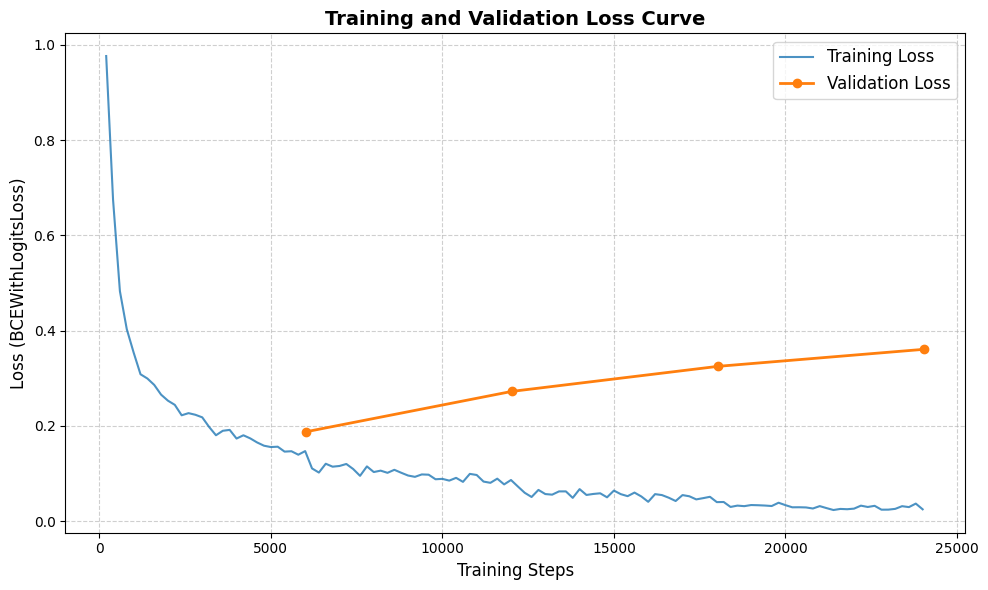


--- FIX 5: Tìm optimal threshold trên valid set ---


  Toxic: best threshold = 0.3221 (F1 = 0.8397)
  Spam: best threshold = 0.5691 (F1 = 0.9373)

Sử dụng threshold: Toxic=0.3221 | Spam=0.5691



TOXIC CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9694    0.9729    0.9711     12072
           1     0.8444    0.8271    0.8357      2146

    accuracy                         0.9509     14218
   macro avg     0.9069    0.9000    0.9034     14218
weighted avg     0.9505    0.9509    0.9507     14218


SPAM CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9863    0.9908    0.9885     12147
           1     0.9444    0.9194    0.9317      2071

    accuracy                         0.9804     14218
   macro avg     0.9654    0.9551    0.9601     14218
weighted avg     0.9802    0.9804    0.9803     14218


Overall Macro F1 (multi-label, sklearn): 0.8837

ROC-AUC Toxic: 0.9773
ROC-AUC Spam : 0.9876

TOXIC CONFUSION MATRIX


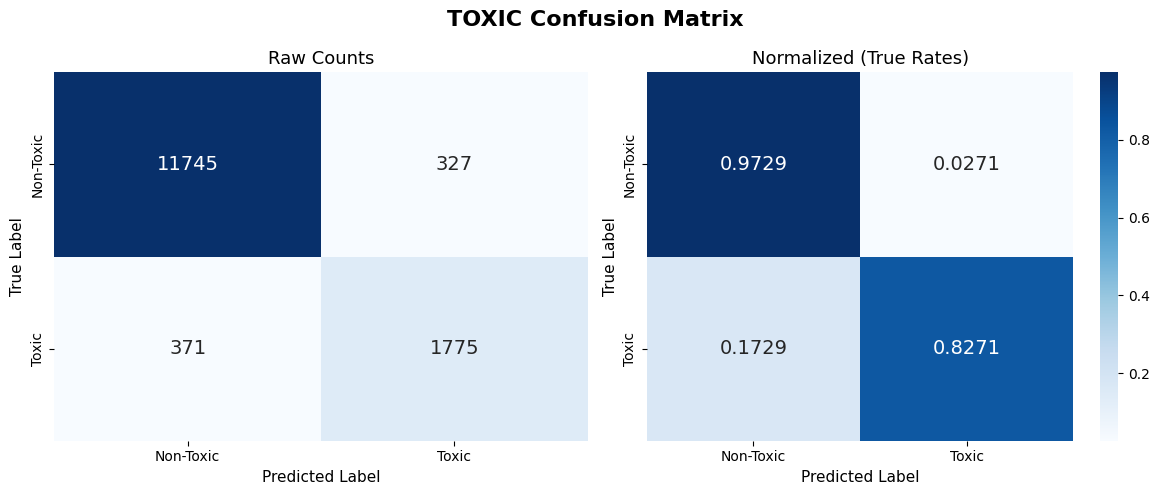


SPAM CONFUSION MATRIX


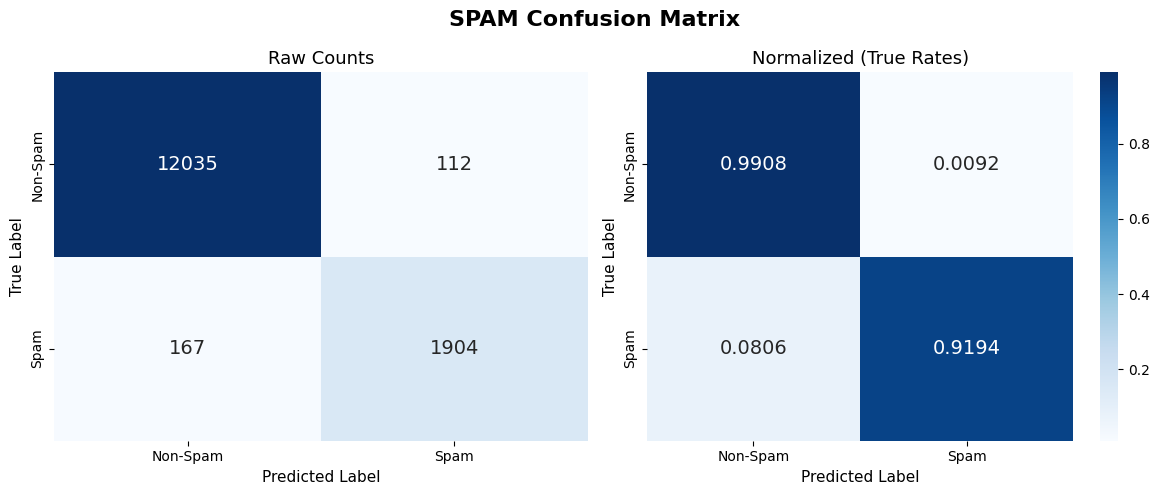


PER-SOURCE BREAKDOWN

[EnglishSpam] n=845
  Toxic F1  : 0.0000
  Spam  F1  : 0.9950
  Macro F1  : 0.4975

[Jigsaw] n=8434
  Toxic F1  : 0.8693
  Spam  F1  : 0.0000
  Macro F1  : 0.4347

[SyntheticHam] n=481
  Toxic F1  : 0.0000
  Spam  F1  : 0.0000
  Macro F1  : 0.0000

[SyntheticSpam] n=947
  Toxic F1  : 0.0000
  Spam  F1  : 0.9877
  Macro F1  : 0.4939

[ViCTSD] n=474
  Toxic F1  : 0.0000
  Spam  F1  : 0.0000
  Macro F1  : 0.0000

[ViHSD] n=1814
  Toxic F1  : 0.7467
  Spam  F1  : 0.0000
  Macro F1  : 0.3734

[ViSpamReviews] n=1223
  Toxic F1  : 0.0000
  Spam  F1  : 0.7946
  Macro F1  : 0.3973

PER-LANGUAGE BREAKDOWN

[lang=en] n=9279
  Toxic F1  : 0.8688
  Spam  F1  : 0.9901
  Macro F1  : 0.9294

[lang=vi] n=4939
  Toxic F1  : 0.7384
  Spam  F1  : 0.9072
  Macro F1  : 0.8228

ERROR ANALYSIS BY SOURCE

--- TOXIC ---
False Positives by source:
source
Jigsaw           218
ViHSD             95
ViCTSD             7
ViSpamReviews      3
EnglishSpam        2
SyntheticHam       1
SyntheticSp

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MODEL SAVED to: ./final_moderation_model_v2

STEP 9 DONE.


In [11]:
# =========================================================
# STEP 9 — FINAL EVALUATION
# =========================================================
# FIX 5: Tìm threshold tối ưu trên valid set cho từng task
#         thay vì dùng 0.5 cố định
# =========================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("STEP 9 - FINAL EVALUATION (FIXED)")
print("=" * 80)

# =========================================================
# VẼ BIỂU ĐỒ TRAINING & VALIDATION LOSS
# =========================================================
print("\n--- Vẽ biểu đồ Loss ---")
log_history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

for log in log_history:
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log and "step" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="#1f77b4", alpha=0.8)

# Đảm bảo có dữ liệu eval_loss thì mới vẽ
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", color="#ff7f0e", marker="o", linewidth=2)

plt.title("Training and Validation Loss Curve", fontsize=14, fontweight="bold")
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss (BCEWithLogitsLoss)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()




# --- FIX 5: Tìm optimal threshold trên valid set ---
print("\n--- FIX 5: Tìm optimal threshold trên valid set ---")

valid_preds = trainer.predict(valid_dataset)
val_logits  = valid_preds.predictions
val_labels  = valid_preds.label_ids
val_probs   = torch.sigmoid(torch.tensor(val_logits)).numpy()

def find_best_threshold(probs_col, labels_col, task_name):
    precisions, recalls, thresholds = precision_recall_curve(labels_col, probs_col)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])   # thresholds có len nhỏ hơn 1
    best_t   = thresholds[best_idx]
    best_f1  = f1s[best_idx]
    print(f"  {task_name}: best threshold = {best_t:.4f} (F1 = {best_f1:.4f})")
    return float(best_t)

THRESHOLD_TOXIC = find_best_threshold(
    val_probs[:, 0], val_labels[:, 0].astype(int), "Toxic"
)
THRESHOLD_SPAM = find_best_threshold(
    val_probs[:, 1], val_labels[:, 1].astype(int), "Spam"
)

print(f"\nSử dụng threshold: Toxic={THRESHOLD_TOXIC:.4f} | Spam={THRESHOLD_SPAM:.4f}")

# --- Predict trên test set ---
predictions = trainer.predict(test_dataset)
logits      = predictions.predictions
labels      = predictions.label_ids
probs       = torch.sigmoid(torch.tensor(logits)).numpy()

# FIX 5: Áp dụng threshold riêng cho từng task
preds = np.zeros_like(probs, dtype=int)
preds[:, 0] = (probs[:, 0] >= THRESHOLD_TOXIC).astype(int)
preds[:, 1] = (probs[:, 1] >= THRESHOLD_SPAM).astype(int)

# --- Reports ---
print("\n" + "=" * 80)
print("TOXIC CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(labels[:, 0].astype(int), preds[:, 0], digits=4))

print("\n" + "=" * 80)
print("SPAM CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(labels[:, 1].astype(int), preds[:, 1], digits=4))

macro_f1_overall = f1_score(labels.astype(int), preds, average="macro")
print(f"\nOverall Macro F1 (multi-label, sklearn): {macro_f1_overall:.4f}")

try:
    print(f"\nROC-AUC Toxic: {roc_auc_score(labels[:, 0].astype(int), probs[:, 0]):.4f}")
    print(f"ROC-AUC Spam : {roc_auc_score(labels[:, 1].astype(int), probs[:, 1]):.4f}")
except Exception as e:
    print(f"ROC-AUC error: {e}")

# =========================================================
# VẼ CONFUSION MATRIX (BEAUTIFUL HEATMAP)
# =========================================================
for task, col in [("TOXIC", 0), ("SPAM", 1)]:
    print(f"\n{'='*80}\n{task} CONFUSION MATRIX\n{'='*80}")
    
    # Tính toán CM
    cm = confusion_matrix(labels[:, col].astype(int), preds[:, col])
    cm_norm = confusion_matrix(labels[:, col].astype(int), preds[:, col], normalize="true")
    
    # Thiết lập khung vẽ (1 hàng, 2 cột để hiện cả Raw và Normalized)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{task} Confusion Matrix", fontsize=16, fontweight="bold")
    
    # Vẽ Raw CM
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                cbar=False, annot_kws={"size": 14})
    axes[0].set_title("Raw Counts", fontsize=13)
    axes[0].set_xlabel("Predicted Label", fontsize=11)
    axes[0].set_ylabel("True Label", fontsize=11)
    axes[0].set_xticklabels(["Non-" + task.title(), task.title()])
    axes[0].set_yticklabels(["Non-" + task.title(), task.title()])
    
    # Vẽ Normalized CM
    sns.heatmap(cm_norm, annot=True, fmt=".4f", cmap="Blues", ax=axes[1],
                cbar=True, annot_kws={"size": 14})
    axes[1].set_title("Normalized (True Rates)", fontsize=13)
    axes[1].set_xlabel("Predicted Label", fontsize=11)
    axes[1].set_ylabel("True Label", fontsize=11)
    axes[1].set_xticklabels(["Non-" + task.title(), task.title()])
    axes[1].set_yticklabels(["Non-" + task.title(), task.title()])
    
    plt.tight_layout()
    plt.show()

# Per-source breakdown
print("\n" + "=" * 80)
print("PER-SOURCE BREAKDOWN")
print("=" * 80)

result_df = test_df.copy()
result_df["toxic_pred"] = preds[:, 0]
result_df["spam_pred"]  = preds[:, 1]
result_df["toxic_prob"] = probs[:, 0]
result_df["spam_prob"]  = probs[:, 1]

for source, grp in result_df.groupby("source"):
    if len(grp) < 5:
        continue
    tf = f1_score(grp["toxic"].astype(int), grp["toxic_pred"], average="binary", zero_division=0)
    sf = f1_score(grp["spam"].astype(int),  grp["spam_pred"],  average="binary", zero_division=0)
    mf = f1_score(
        grp[["toxic","spam"]].astype(int).values,
        grp[["toxic_pred","spam_pred"]].values,
        average="macro", zero_division=0
    )
    print(f"\n[{source}] n={len(grp)}")
    print(f"  Toxic F1  : {tf:.4f}")
    print(f"  Spam  F1  : {sf:.4f}")
    print(f"  Macro F1  : {mf:.4f}")

# Per-language breakdown
print("\n" + "=" * 80)
print("PER-LANGUAGE BREAKDOWN")
print("=" * 80)

for lang, grp in result_df.groupby("lang"):
    if len(grp) < 5:
        continue
    tf = f1_score(grp["toxic"].astype(int), grp["toxic_pred"], average="binary", zero_division=0)
    sf = f1_score(grp["spam"].astype(int),  grp["spam_pred"],  average="binary", zero_division=0)
    mf = f1_score(
        grp[["toxic","spam"]].astype(int).values,
        grp[["toxic_pred","spam_pred"]].values,
        average="macro", zero_division=0
    )
    print(f"\n[lang={lang}] n={len(grp)}")
    print(f"  Toxic F1  : {tf:.4f}")
    print(f"  Spam  F1  : {sf:.4f}")
    print(f"  Macro F1  : {mf:.4f}")

# Error analysis
print("\n" + "=" * 80)
print("ERROR ANALYSIS BY SOURCE")
print("=" * 80)

for task, true_col, pred_col in [("TOXIC","toxic","toxic_pred"),("SPAM","spam","spam_pred")]:
    print(f"\n--- {task} ---")
    fp_mask = (result_df[true_col] == 0) & (result_df[pred_col] == 1)
    fn_mask = (result_df[true_col] == 1) & (result_df[pred_col] == 0)
    print(f"False Positives by source:")
    print(result_df[fp_mask]["source"].value_counts().to_string())
    print(f"\nFalse Negatives by source:")
    print(result_df[fn_mask]["source"].value_counts().to_string())

# Sample predictions
print("\n" + "=" * 80)
print("SAMPLE PREDICTIONS")
print("=" * 80)

for idx, row in result_df.sample(10, random_state=42).iterrows():
    print("\n" + "-" * 60)
    print(f"TEXT:\n{row['text']}")
    print(f"SOURCE: {row['source']} | LANG: {row['lang']}")
    print(f"TRUE:  Toxic={int(row['toxic'])} | Spam={int(row['spam'])}")
    print(f"PRED:  Toxic={row['toxic_pred']} ({row['toxic_prob']:.4f}) | Spam={row['spam_pred']} ({row['spam_prob']:.4f})")

# Save
SAVE_PATH = "./final_moderation_model_v2"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("\n" + "=" * 80)
print(f"MODEL SAVED to: {SAVE_PATH}")
print("=" * 80)
print("\nSTEP 9 DONE.")